# AdaBoost and Gradient Boosting Regression – Hotel Reservation Dataset


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor


In [4]:

# Load dataset
df = pd.read_csv("Reservation Regression.csv")


In [5]:

# Drop unnecessary columns
df = df.drop([
    'reservation_status',
    'reservation_status_date',
    'arrival_date_month'
], axis=1)


In [6]:

# Handle missing values (Pandas 3.0 safe)
df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna('UNK')
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)


In [7]:

# Encode categorical variables
le = LabelEncoder()
for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])


In [8]:

# Feature-target split
X = df.drop('adr', axis=1)
y = df['adr']


In [9]:

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [12]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor

# AdaBoost Regressor (FIXED)
ada = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=4),
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

ada.fit(X_train, y_train)
ada_pred = ada.predict(X_test)


In [13]:

# Gradient Boosting Regressor
gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)
gbr.fit(X_train, y_train)
gbr_pred = gbr.predict(X_test)


In [14]:

# Evaluation
print("AdaBoost Regressor")
print("MSE:", mean_squared_error(y_test, ada_pred))
print("R2 Score:", r2_score(y_test, ada_pred))

print("\nGradient Boosting Regressor")
print("MSE:", mean_squared_error(y_test, gbr_pred))
print("R2 Score:", r2_score(y_test, gbr_pred))


AdaBoost Regressor
MSE: 1374.6459182837614
R2 Score: 0.39892626061058645

Gradient Boosting Regressor
MSE: 452.5705674679049
R2 Score: 0.8021102891243816


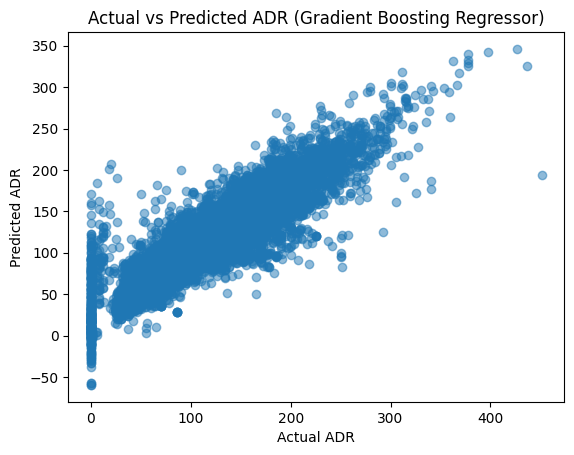

In [15]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, gbr_pred, alpha=0.5)
plt.xlabel("Actual ADR")
plt.ylabel("Predicted ADR")
plt.title("Actual vs Predicted ADR (Gradient Boosting Regressor)")
plt.show()


# Implementation of AdaBoost and Gradient Boosting Classifier on Diabetes Dataset


In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier


In [17]:

# Load dataset
df = pd.read_csv("diabetes.csv")


In [18]:

# Feature-target split
X = df.drop('Outcome', axis=1)
y = df['Outcome']


In [19]:

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [20]:

# AdaBoost Classifier (new sklearn syntax)
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2),
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
ada.fit(X_train, y_train)
ada_pred = ada.predict(X_test)


In [21]:

# Gradient Boosting Classifier
gbr = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr.fit(X_train, y_train)
gbr_pred = gbr.predict(X_test)


In [22]:

# Evaluation
print("AdaBoost Classifier Accuracy:", accuracy_score(y_test, ada_pred))
print("Gradient Boosting Classifier Accuracy:", accuracy_score(y_test, gbr_pred))

print("\nConfusion Matrix (Gradient Boosting):")
print(confusion_matrix(y_test, gbr_pred))

print("\nClassification Report (Gradient Boosting):")
print(classification_report(y_test, gbr_pred))


AdaBoost Classifier Accuracy: 0.7662337662337663
Gradient Boosting Classifier Accuracy: 0.7467532467532467

Confusion Matrix (Gradient Boosting):
[[77 22]
 [17 38]]

Classification Report (Gradient Boosting):
              precision    recall  f1-score   support

           0       0.82      0.78      0.80        99
           1       0.63      0.69      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



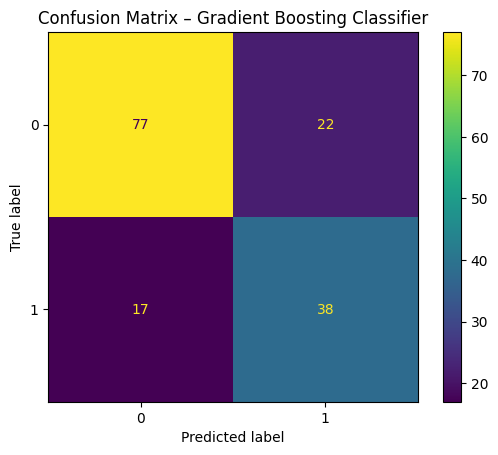

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    gbr_pred
)

plt.title("Confusion Matrix – Gradient Boosting Classifier")
plt.show()
